<h1> Appendix A: Numerical Analysis </h1>
<h3> Hull-White Model Based Deep BSDE Solver for Bermudan Swaption Pricing </h3>

This Python notebook illustrates how to set up and use a `DeepBSDESolver`, implemented in the class `DeepBackwardBSDE`, together with its core methods `.fit()` and `.evaluate()`, as well as auxiliary helpers for activation functions and intrinsic swaption value computation. The implementation is located in `src/BSDESolver.py` and builds on the existing library provided by the *Interest Rate Modelling Examples*.

> **Important Note.** Some cells in this notebook may require a lot of computation time due to network training. If so, a progress bar will appear showing the progress and remaining time executing.

All numerical experiments were executed on a laptop equipped with an Intel Core i7-1360P (13th generation, 2.20 GHz) CPU and 16 GB of RAM, running a 64-bit operating system. No GPU was used.


<h4> Import of relevant packages <h4>

In [2]:
import sys, os, importlib, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(".."))
os.makedirs("plots", exist_ok=True)

In [3]:
import numpy as np, pandas as pd, torch, torch.nn as nn, time, QuantLib as ql
from scipy.optimize import brentq
from tqdm import tqdm

In [4]:
from src.yieldcurve import YieldCurve
from src.hull_white_model import HullWhiteModel
from src.swaption import create_swaption, Swaption
from src.bermudan_option import bermudan_option_npv
from src.monte_carlo_simulation import MonteCarloSimulation
from src.methods.payoffs import CouponBond
from src.methods.amc_solver import AmcSolver, StateVariableControls
from src.methods.pde_solver import PdeSolver

In [5]:
import src.BSDESolver as BSDESolver
importlib.reload(BSDESolver)
from src.BSDESolver import BsdeBackwardSolver, Calibration, PlotHelpers

<h4> Yield Curve Setup <h4> 

In [6]:
ql.Settings.instance().evaluationDate = ql.Date(2, ql.January, 2025)

In [7]:
terms = [    '1y',    '2y',    '3y',    '4y',    '5y',    '6y',    '7y',    '8y',    '9y',   
                                '10y',   '12y',   '15y',   '20y',   '25y',   '30y', '50y'   ] 
rates = [2.70e-2, 2.75e-2, 2.80e-2, 3.00e-2, 3.36e-2, 3.68e-2, 3.97e-2, 4.24e-2, 4.50e-2, 
                              4.75e-2, 4.75e-2, 4.70e-2, 4.50e-2, 4.30e-2, 4.30e-2, 4.30e-2] 
yc = YieldCurve(terms, rates)

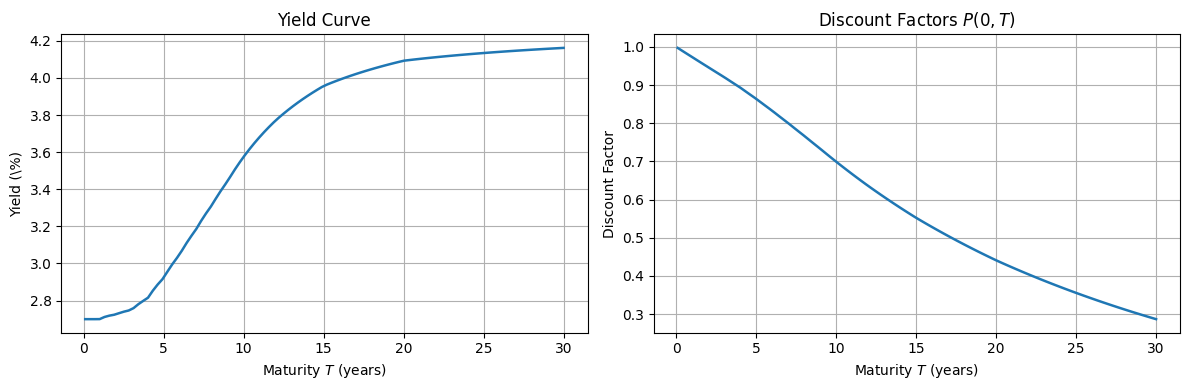

In [8]:
fig, axes = PlotHelpers.plot_yield_and_discount_curve(yc)

In [9]:
yc.table()

,Terms,Dates,Rates
0,0d,"January 2nd, 2025",0.027
1,1y,"January 2nd, 2026",0.027
2,2y,"January 4th, 2027",0.0275
3,3y,"January 3rd, 2028",0.028
4,4y,"January 2nd, 2029",0.03
5,5y,"January 2nd, 2030",0.0336
6,6y,"January 2nd, 2031",0.0368
7,7y,"January 2nd, 2032",0.0397
8,8y,"January 3rd, 2033",0.0424
9,9y,"January 2nd, 2034",0.045


<h4> Model and swaption setup <h4>

In [10]:
maturity = 20
strike   = 0.03
mkt_vol  = 100 * 1e-4
a_hw     = 0.05

In [11]:
expiry_terms = [f"{e}y" for e in range(1, maturity)]
swap_terms   = [f"{maturity-e}y" for e in range(1, maturity)]

In [12]:
swpts = [create_swaption(e, s, yc, yc, strike=strike, normalVolatility=mkt_vol, 
         payerOrReceiver=ql.VanillaSwap.Receiver) 
         for e, s in zip(expiry_terms, swap_terms)]

In [13]:
hw = Calibration.model_from_swaptions(swpts, yc, mean_reversion=a_hw)

In [14]:
print("mean reversion a =", a_hw)
print("sigma(t) at t=1y:", hw.sigma(1.0))

mean reversion a = 0.05
sigma(t) at t=1y: 0.015163699312239999


In [15]:
details = [s.bond_option_details() for s in swpts]
exercise_times = np.array([d['expiry_time'] for d in details])
print(exercise_times)

[ 1.          2.00547945  3.00273973  4.00273973  5.00273973  6.00273973
  7.00273973  8.00821918  9.00547945 10.00547945 11.00547945 12.00821918
 13.01369863 14.0109589  15.00821918 16.0109589  17.0109589  18.0109589
 19.01643836]


The final grid `t_grid` is set up by unique concatenation of the exercise dates and a grid refinement called `base_grid`. We will analyze the impact of the refinement grid later in the examples.

In [16]:
T_max = float(max(d['pay_times'][-1] for d in details))
base_grid = np.linspace(0.0, T_max, 102)
t_grid = np.unique(np.sort(np.concatenate([base_grid, exercise_times])))

<h4> Sample paths of the interest rate <h4>

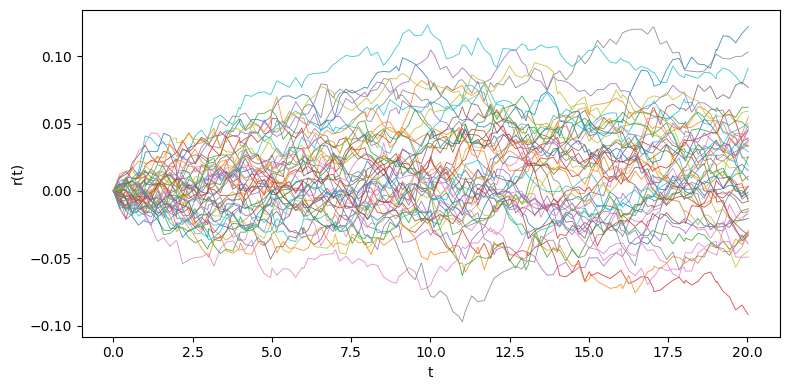

In [17]:
sim_plot = MonteCarloSimulation(hw, t_grid, n_paths=50, seed=42, showProgress=False)
plt.figure(figsize=(8, 4))
for i in range(50):
    plt.plot(sim_plot.times, sim_plot.X[:, 0, i], lw=0.6, alpha=0.85)
plt.xlabel("t")
plt.ylabel("r(t)")
plt.tight_layout()
plt.savefig("plots/3_hw_paths.png", dpi=300)

In [18]:
print(f"Mean reversion a: {hw.mean_reversion}")
print(f"Volatility times: {hw.volatility_times}")
print(f"Volatility values: {hw.volatility_values}")

Mean reversion a: 0.05
Volatility times: [ 1.          2.00547945  3.00273973  4.00273973  5.00273973  6.00273973
  7.00273973  8.00821918  9.00547945 10.00547945 11.00547945 12.00821918
 13.01369863 14.0109589  15.00821918 16.0109589  17.0109589  18.0109589
 19.01643836]
Volatility values: [0.0151637  0.01522704 0.01521592 0.01519308 0.01518258 0.01519829
 0.01518388 0.01520471 0.01521926 0.01528247 0.01521091 0.01520834
 0.01498821 0.01487921 0.01476134 0.0145682  0.01433147 0.01406866
 0.01370639]


<h4> Bermudan Swaption and Solver Setup <h4>

In [19]:
underlying_payoffs = [CouponBond(hw, d['expiry_time'], 
d['pay_times'], d['cash_flows'] * d['call_or_put']) for d in details]
ex_idx = [np.where(np.isclose(t_grid, t, rtol=0, atol=1e-12))[0][0] 
          for t in exercise_times]

Setup of the Deep BSDE Solver. We specify a network architecture which has properties which performed well during the Numerical Experiments, that is 5 layers which a sufficient amount of nodes, symmetrical structure and softplus activation function, together with a learning rate of $\mathrm{lr}=0.01$.

In [20]:
bsde1 = BsdeBackwardSolver(
    hw_model=hw,                           # Hull White model
    times=t_grid,                          # Helper Time Grid (Final Time Gripd is t_grid concatenated 
                                           # with the Bermudan Exercise Dates)
    payoffs=underlying_payoffs,            # Underlying Payoffs
    exercise_indices=ex_idx,               # Bermudan Exercise Dates
    payer=False,                           # Payer or Receiver underlying Swap
    architecture=(16, 32, 64, 32, 16),     # architecture of layers and nodes of the used neural network
    activation="relu",                     # activation function
    lr=0.1,                                # learning rate
    seed=123                               # seed
)

We can use the `.fit()` method in the DeepBSDE Solver to train the Neural Network specified in the `BsdeBackwardSolver` object.

In [20]:
n_paths, n_epochs = 50000, 600
bsde1.losses,bsde1.y0_vals = [], []
t0 = time.perf_counter()
bsde1.fit(n_epochs=n_epochs, n_paths=n_paths)
elapsed1 = time.perf_counter() - t0
berm_price_bsde1 = bsde1.y0_vals[-1]
epochs_displayed = [1, 10, 20, 50, 80, 100, 200, 600]
rows = []
for epoch in epochs_displayed:
    rows.append({"Epoch": epoch, 
                 "Loss Var[u₀]": bsde1.losses[epoch - 1], 
                 "Price E[Y₀]": bsde1.y0_vals[epoch - 1]})

BSDE training:   0%|          | 0/600 [00:00<?, ?it/s]

In [21]:
pd.DataFrame(rows).round(3)

,Epoch,Loss Var[u₀],Price E[Y₀]
0,1,55.451,974.724
1,10,28.668,942.823
2,20,15.896,804.528
3,50,4.060,688.725
4,80,1.547,627.468
5,100,0.991,610.809
6,200,0.807,607.876
7,600,0.812,604.035


For most test cases, the BSDE-based approach yields price estimates that are close to those obtained with the AMC method. In the majority of examples, the BSDE price lies between the corresponding AMC and PDE prices.

In [34]:
amc_method = AmcSolver(simulation=MonteCarloSimulation(hw, t_grid, n_paths=n_paths, seed=123), 
                       max_polynomial_degree=2, split_ratio=0.25, controls=StateVariableControls())
npv_amc = bermudan_option_npv(exercise_times, underlying_payoffs, amc_method, showProgress=True)
pde_method = PdeSolver(hw)
npv_pde = bermudan_option_npv(exercise_times, underlying_payoffs, pde_method, showProgress=True)

Backward induction: 100%|██████████| 19/19 [00:00<00:00, 142.78it/s]


In [23]:
PlotHelpers.BermTable(details, exercise_times, 
    berm_price_bsde1, npv_amc, npv_pde, elapsed1)


Bermudan swaption summary
----------------------------------------------------------------------
Side                : Receiver
Exercise dates      : 19
Exercise window     : [1.00, 19.02] years
Final maturity      : 20.02 years
Runtime             : 3610.37 s
----------------------------------------------------------------------
Method     |        Price |   Rel. error
----------------------------------------------------------------------
BSDE       |   604.034669 |            —
AMC        |   604.853545 |      -0.0014
PDE        |   576.403715 |       0.0479
----------------------------------------------------------------------


We observe a stable training and fast convergence, the loss decreases steadily. Though, bringing it really close to zero is difficult. This might be due to the fact, that the loss function is the variance of the option price, which is hard to minimize and a computationally expensive choice of loss function. 

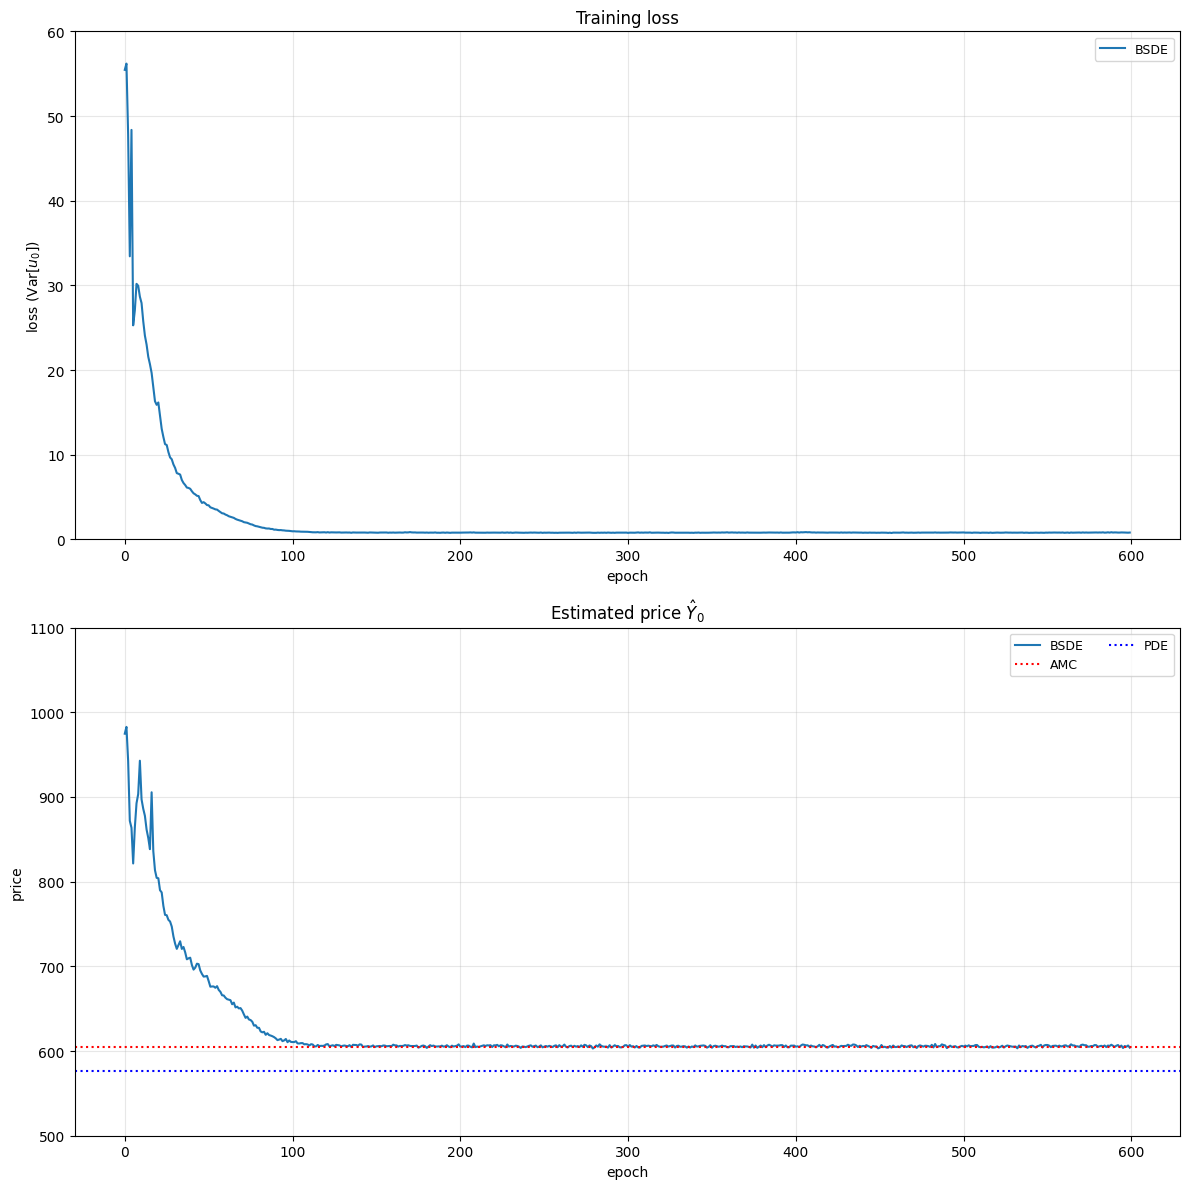

In [24]:
import src.BSDESolver as BSDESolver
importlib.reload(BSDESolver)
from src.BSDESolver import BsdeBackwardSolver, Calibration, PlotHelpers
PlotHelpers.plot_bsde_training(solvers=[("BSDE", bsde1)], 
    filename="plots/4_optimum_training.png", npv_amc=npv_amc, npv_pde=npv_pde)

<h4> Option price distribution </h4>

In [21]:
bsde0 = BsdeBackwardSolver(hw_model=hw, times=t_grid, payoffs=underlying_payoffs, 
                exercise_indices=ex_idx, payer=False, architecture=(16, 32, 64, 32, 16), 
                activation="relu", lr=0.01, seed=123)
snapshots = PlotHelpers.train_bsde_with_snapshots(bsde=bsde0, n_paths_train=50000,
                            n_paths_eval=50000, snapshot_epochs=[2, 40, 400, 1000])

BSDE training (snapshots):   0%|          | 0/1000 [00:00<?, ?it/s]

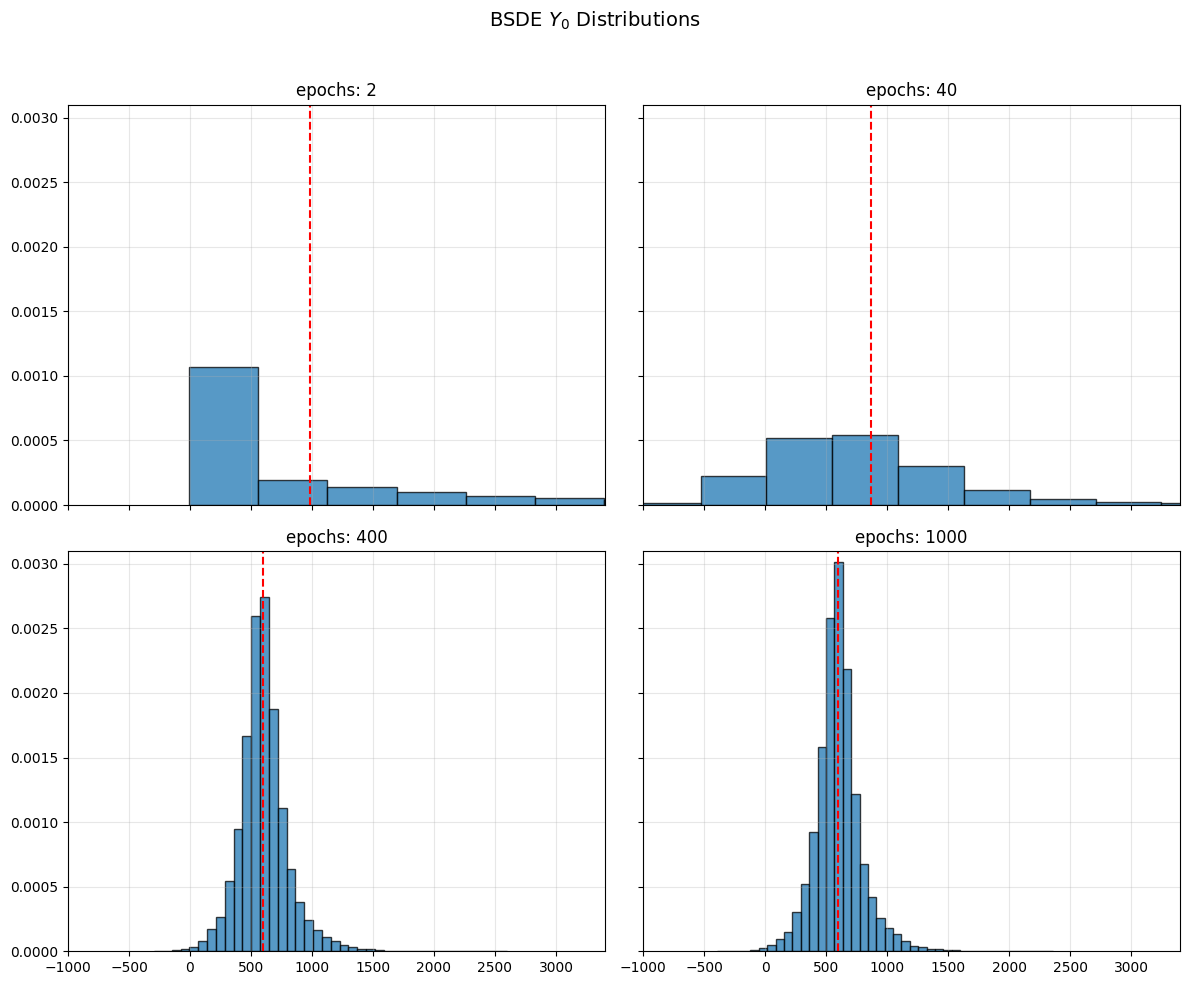

In [26]:
fig, axes = PlotHelpers.plot_y0_snapshots_2x2(results=snapshots, bins=40, 
    xlim=(-1000, 3400), ylim=(0, 0.0031), title_prefix="epochs", figsize=(12, 10), 
    filename="plots/5_Y0_distribution_during_epochs.png",)     

<h3> Path analysis </h3>


In [27]:
results_paths = PlotHelpers.train_bsde_different_paths(hw=hw, t_grid=t_grid, 
    underlying_payoffs=underlying_payoffs, ex_idx=ex_idx, n_epochs=400, 
    path_grid=(50, 200, 2000, 50000), architecture=(16, 32, 64, 32, 16), 
    activation="relu", lr=0.1, seed=123)

BSDE training:   0%|          | 0/400 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/400 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/400 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/400 [00:00<?, ?it/s]

,paths,mean_Y0,std_Y0
0,50,840.6,1067.0
1,200,901.5,997.5
2,2000,623.3,299.8
3,50000,604.9,195.1


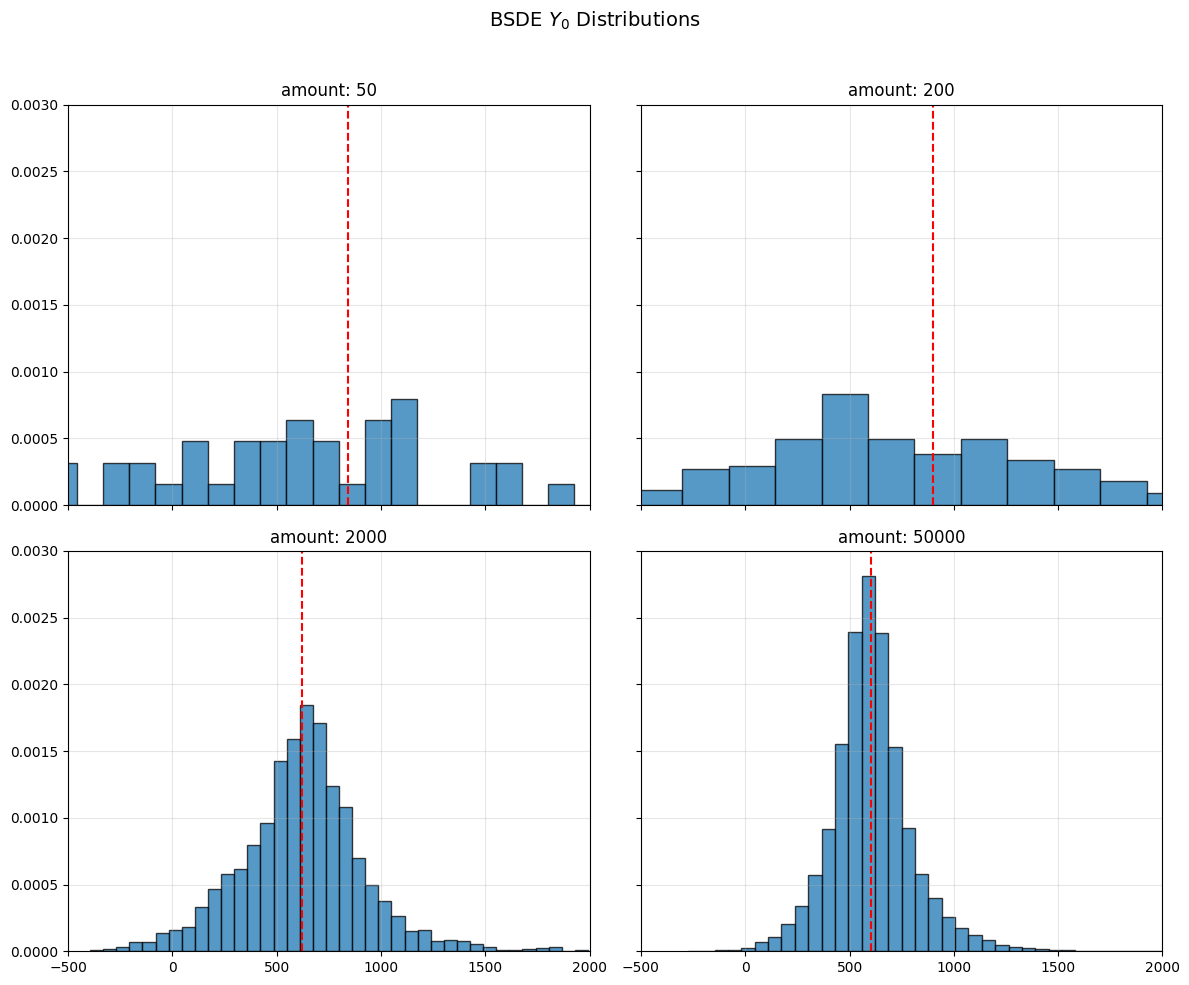

In [31]:
PlotHelpers.plot_y0_paths_with_table(results=results_paths, bins=40, 
    xlim=(-500, 2000), ylim=(0, 0.003), title_prefix="amount", figsize=(12, 10), 
    filename="plots/6_Y0_distribution_for_different_amount_of_paths.png",).round(1)

<h3> Grid size Analysis </h3>

In [ ]:
grid_results = PlotHelpers.run_grid_size_experiment(hw=hw, 
    exercise_times=exercise_times, underlying_payoffs=underlying_payoffs,
    T_max=T_max, grid_sizes=[2, 22, 42, 62, 82, 102, 122, 142, 162, 182, 202], n_epochs=300, 
    n_paths=50000, architecture=(16, 32, 64, 32, 16), activation="relu", lr=0.1, seed=123)

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

...

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

,grid_size,price_bsde,price_amc
0,2,652.1,612.4
1,22,638.1,604.6
2,42,629.1,605.7
3,62,609.1,598.6
4,82,606.0,602.3
5,102,602.5,604.9
6,122,605.7,600.8
7,142,605.1,605.6
8,162,602.0,607.4
9,182,600.0,602.9


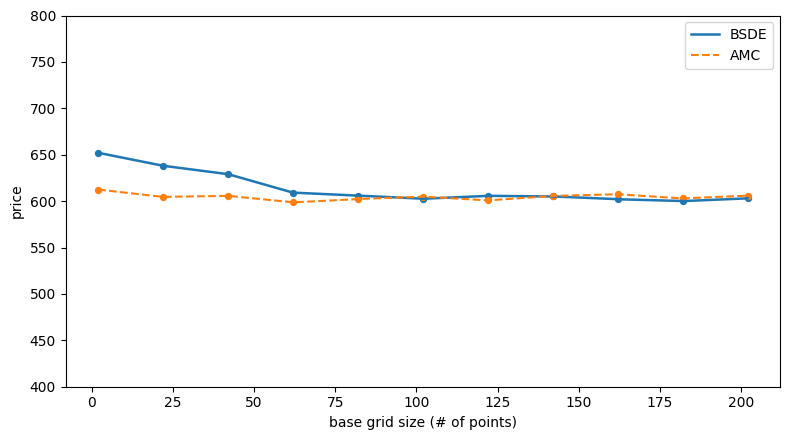

In [ ]:
df = PlotHelpers.show_grid_results(grid_results=grid_results, filename="plots/7_grid_influence_on_Y0.png")

<h4> Analysis of the choice of activation function </h4>

In [32]:
n_paths, n_epochs = 50000, 1000
act_list   = ["relu", "tanh", "sigmoid", "softplus"]
fixed_hs   = (16, 32, 64, 32, 16)
act_solvers = []
for act in act_list:
    bsde = BsdeBackwardSolver(hw_model=hw, times=t_grid, payoffs=underlying_payoffs, 
                exercise_indices=ex_idx, payer=False, 
                architecture=fixed_hs, activation=act, lr=0.1, seed=123)
    bsde.fit(n_epochs=n_epochs, n_paths=n_paths)
    act_solvers.append((f"{act.upper()}", bsde))

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

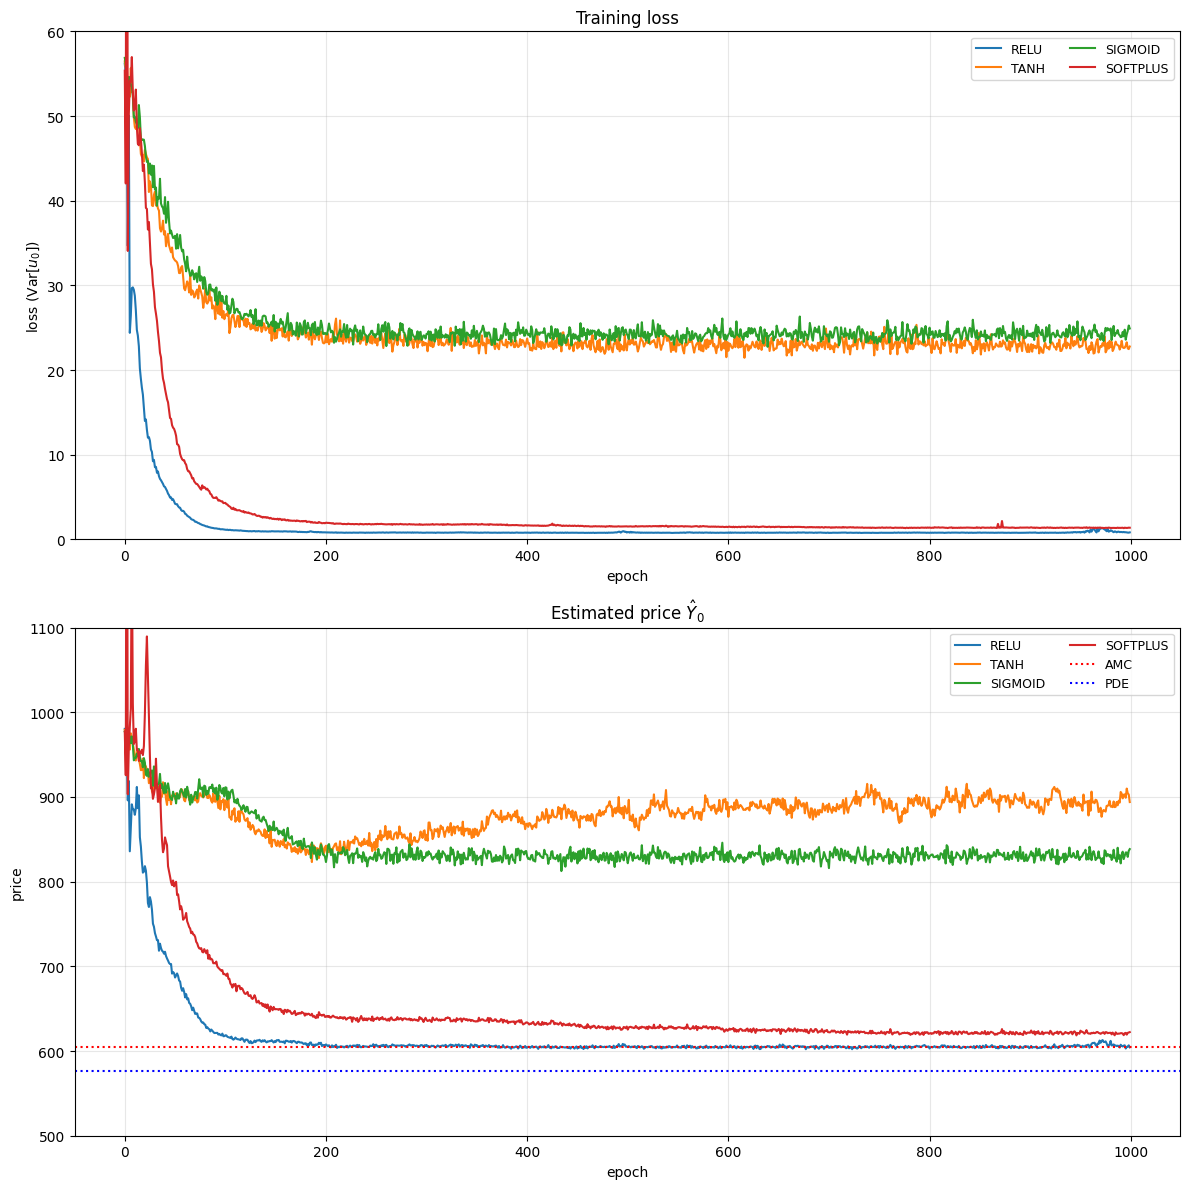

In [35]:
PlotHelpers.plot_bsde_training(solvers=act_solvers, filename="plots/8_activation_comparison.png", npv_amc=npv_amc, npv_pde=npv_pde)

<h4>Network architectures</h4>

The analysis focuses on the following aspects:
- Analysis of symmetric network architectures of the form $(d_i)_{i=1}^n$, where
  $d_i = 2^{k_i} = d_{n+1-i}$ for some $k_i \in \mathbb{N}$ and
  $i \leq \left\lfloor \frac{n}{2} \right\rfloor$,
- Analysis of the network depth (from 1 to 6 layers),
- Analysis of the influence of the number of nodes (1, 2, 4, or 16) per layer in deep networks (6 layers).

In [36]:
# Analysis of symmetric network structures
depths = [(4,), (4,4), (16,16), (16, 32, 64, 32, 16), (16, 32, 64, 64, 32, 16)]
n_paths, n_epochs  = 50000, 1000
depth_solvers = []
for hs in depths:
    name = f"Softplus | ({', '.join(map(str, hs))})"
    sol = BsdeBackwardSolver(hw_model=hw, times=t_grid, payoffs=underlying_payoffs, 
        exercise_indices=ex_idx, payer=False, architecture=hs, 
        activation="relu", lr=0.1, seed=123)
    sol.fit(n_epochs=n_epochs, n_paths=n_paths)
    depth_solvers.append((name, sol))

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

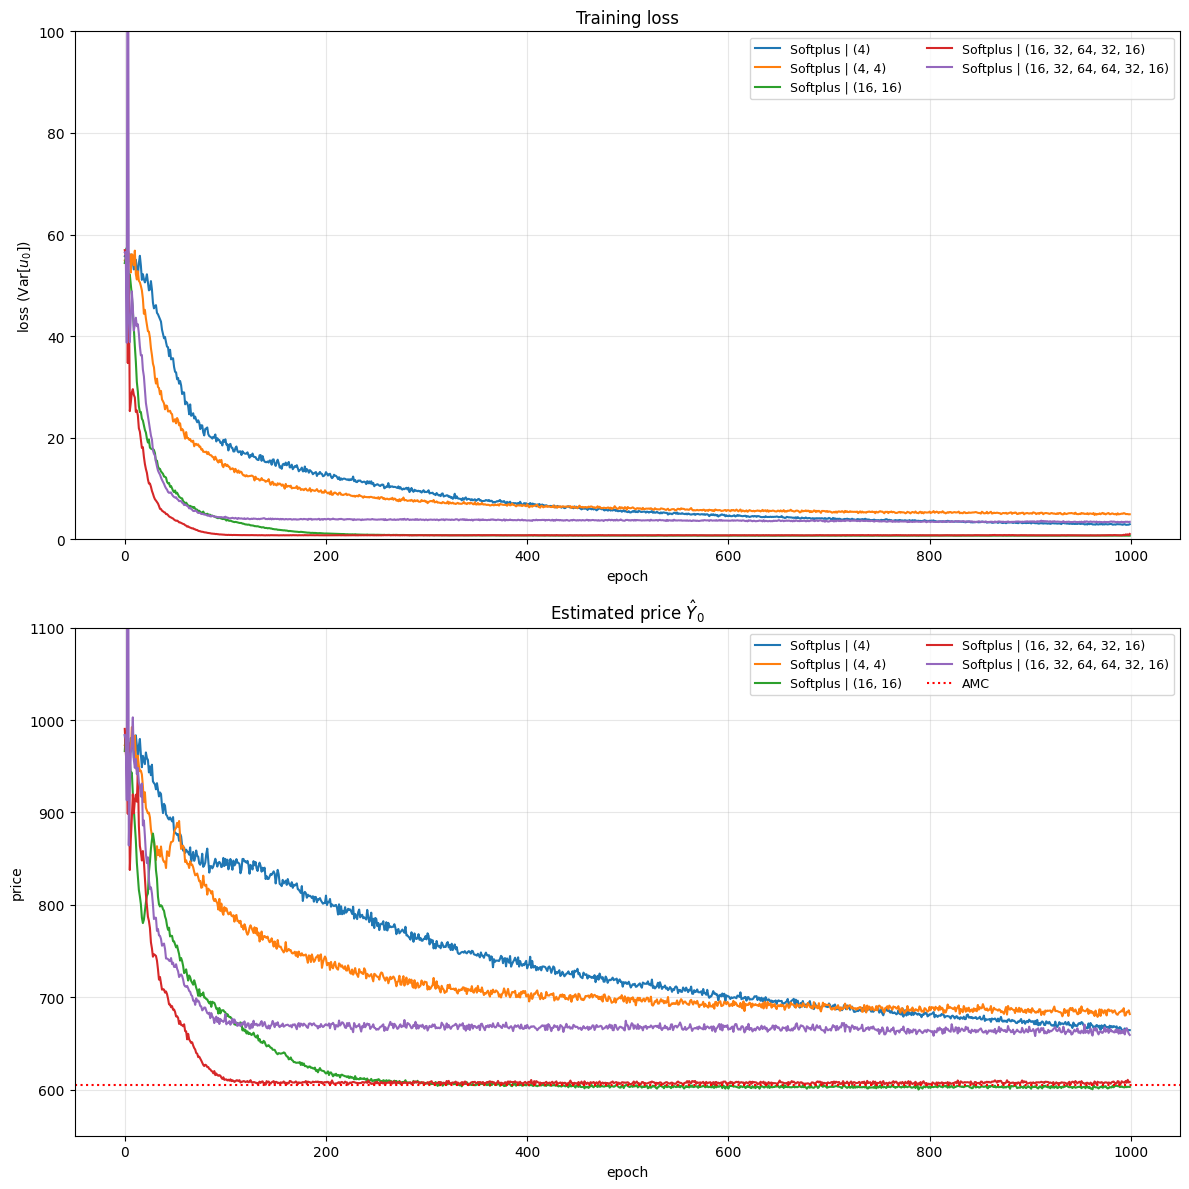

,Architecture,Activation,BSDE price,Rel. err. AMC [%]
0,(4),softplus,664.3109,9.83
1,"(4, 4)",softplus,681.6966,12.70
2,"(16, 16)",softplus,602.7906,-0.34
3,"(16, 32, 64, 32, 16)",softplus,608.1963,0.55
4,"(16, 32, 64, 64, 32, 16)",softplus,659.0886,8.97


In [62]:
PlotHelpers.plot_bsde_training_with_table(solvers=depth_solvers, 
        npv_amc=npv_amc, filename="plots/9_network_depth.png")

In [38]:
# depth analysis
depths = [(16,), (16,16), (16,16,16), (16, 16, 16, 16), 
          (16, 16, 16, 16, 16), (16, 16, 16, 16, 16, 16)]
n_paths, n_epochs  = 50000, 1000
depth_solvers2 = []
for hs in depths:
    name = f"Softplus | {hs}"
    sol = BsdeBackwardSolver( hw_model=hw, times=t_grid, 
        payoffs=underlying_payoffs, exercise_indices=ex_idx, 
        payer=False, architecture=hs, activation="softplus", lr=0.1, seed=123)
    sol.fit(n_epochs=n_epochs, n_paths=n_paths)
    depth_solvers2.append((name, sol))

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

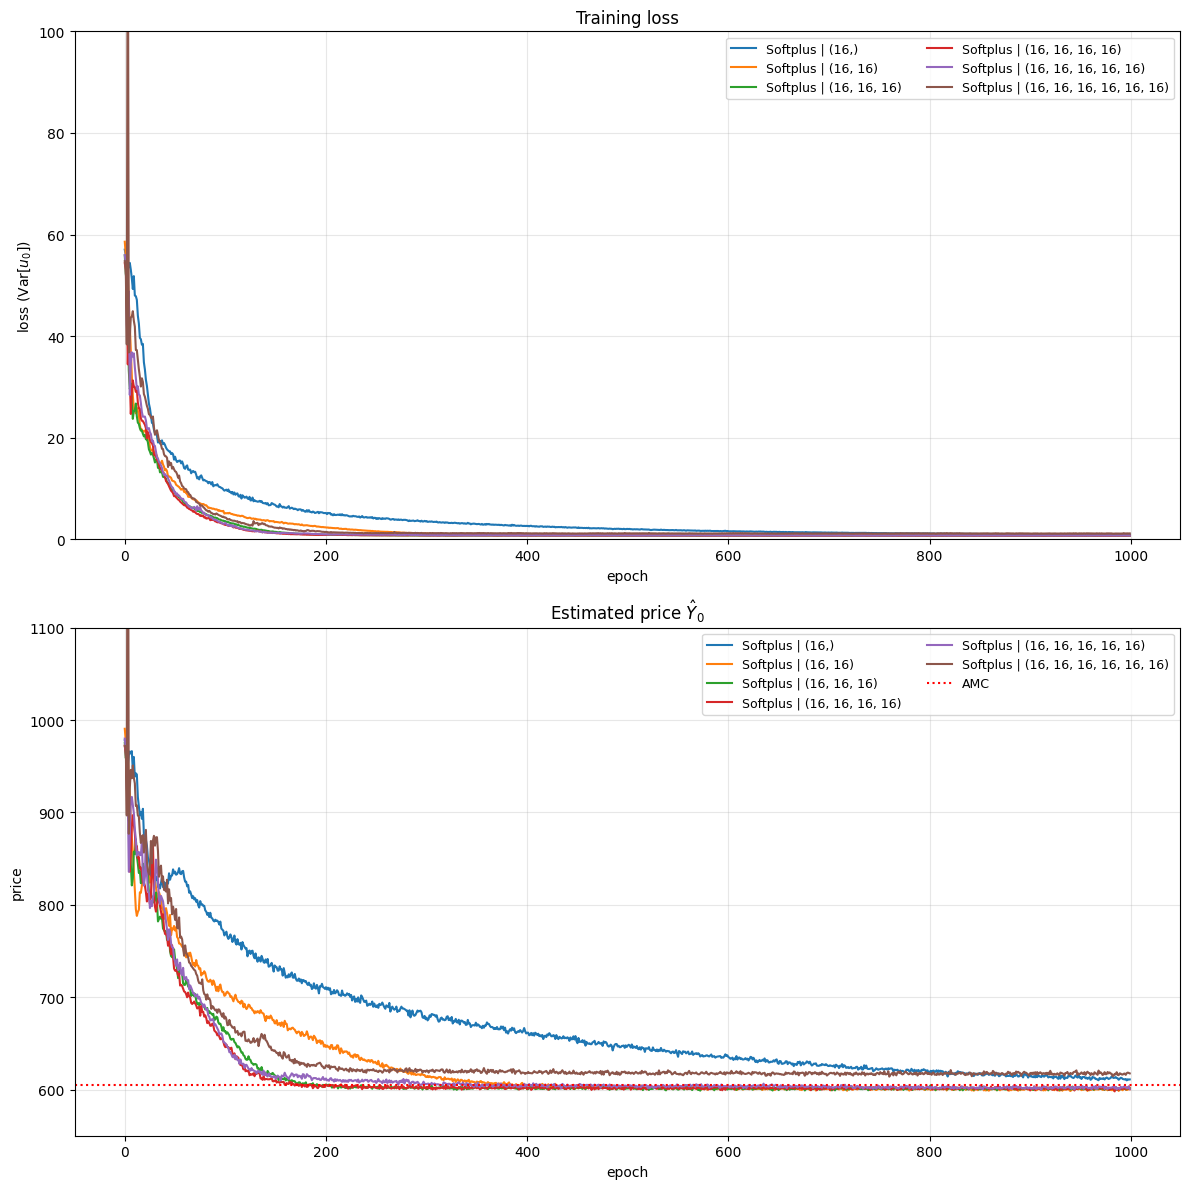

,Architecture,Activation,BSDE price,Rel. err. AMC [%]
0,"(16,)",softplus,610.9346,1.01
1,"(16, 16)",softplus,602.2074,-0.44
2,"(16, 16, 16)",softplus,601.2766,-0.59
3,"(16, 16, 16, 16)",softplus,600.2930,-0.75
4,"(16, 16, 16, 16, 16)",softplus,600.7007,-0.69
5,"(16, 16, 16, 16, 16, 16)",softplus,617.4697,2.09


In [63]:
PlotHelpers.plot_bsde_training_with_table(solvers=depth_solvers2, 
            npv_amc=npv_amc, filename="plots/9_network_depth2.png")

In [65]:
# Analysis of the influence of the amount of nodes per layer in deep networks (6 layers)
depths = [ (1, 1, 1, 1, 1, 1), (2, 2, 2, 2, 2, 2), (4, 4, 4, 4, 4, 4), 
          (16, 16, 16, 16, 16, 16) ,(32, 32, 32, 32, 32, 32)]
n_paths, n_epochs  = 50000, 1000
depth_solvers3 = []
for hs in depths:
    name = f"ReLu | {hs}"
    sol = BsdeBackwardSolver(hw_model=hw, times=t_grid, payoffs=underlying_payoffs, 
            exercise_indices=ex_idx, payer=False, architecture=hs, 
            activation="relu", lr=0.1, seed=123)
    sol.fit(n_epochs=n_epochs, n_paths=n_paths)
    depth_solvers3.append((name, sol))

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

BSDE training:   0%|          | 0/1000 [00:00<?, ?it/s]

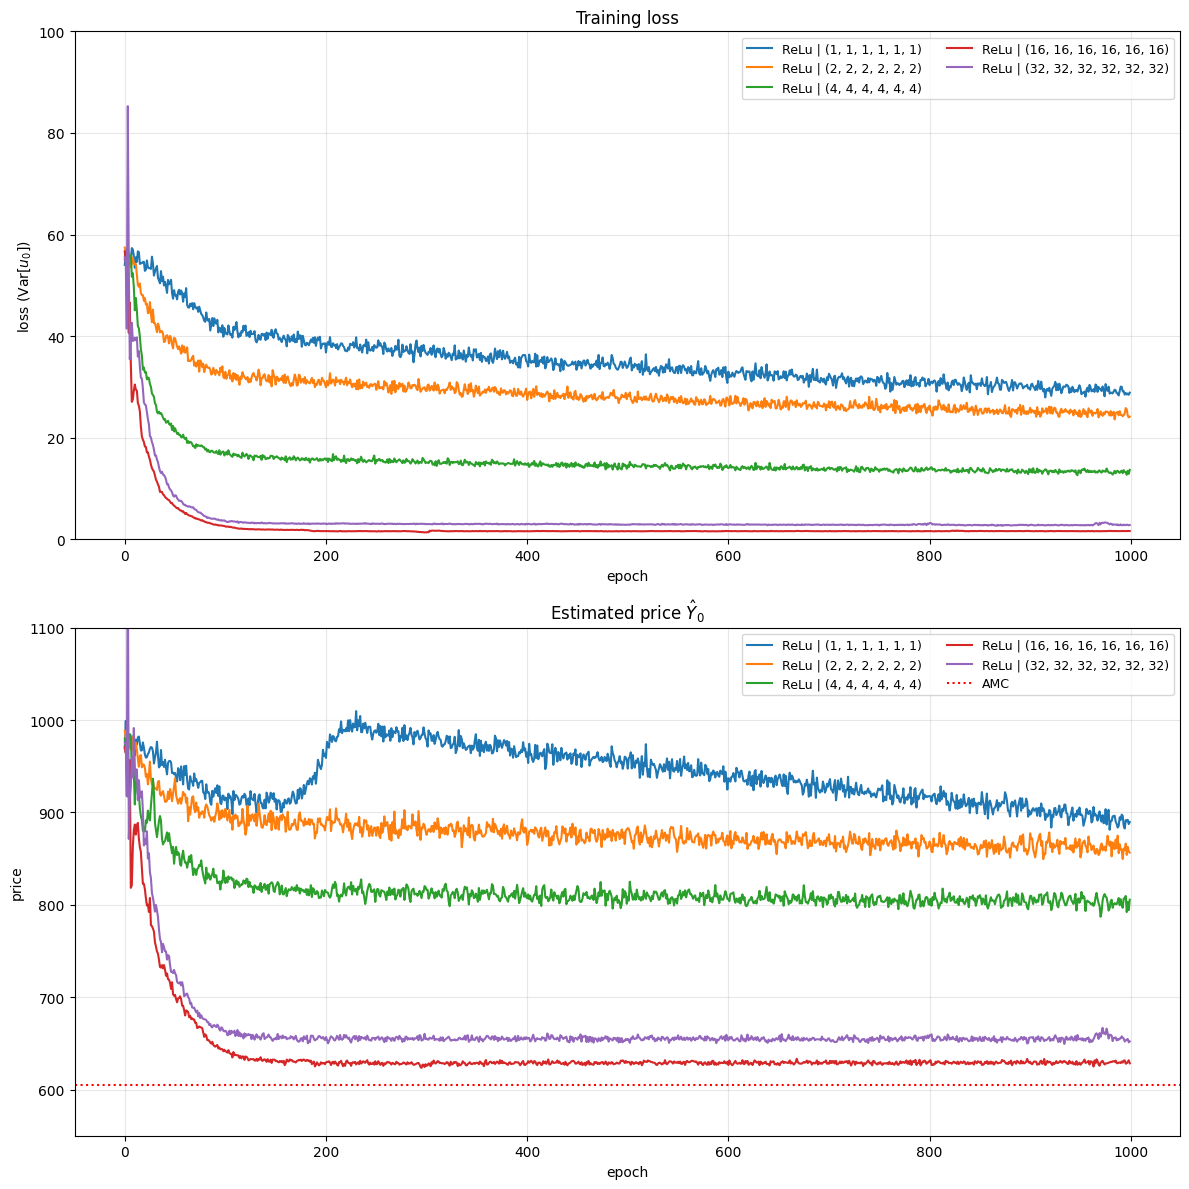

,Architecture,Activation,BSDE price,Rel. err. AMC [%]
0,"(1, 1, 1, 1, 1, 1)",softplus,889.5646,47.07
1,"(2, 2, 2, 2, 2, 2)",softplus,856.4253,41.59
2,"(4, 4, 4, 4, 4, 4)",softplus,805.5082,33.17
3,"(16, 16, 16, 16, 16, 16)",softplus,628.4064,3.89
4,"(32, 32, 32, 32, 32, 32)",softplus,652.0289,7.80


In [66]:
PlotHelpers.plot_bsde_training_with_table(solvers=depth_solvers3, npv_amc=npv_amc, filename="plots/9_network_depth3.png")

<h4> ITM, ATM and OTM Bermudan Swaption Analysis </h4>




For the following Analysis, the Bermudan Pricing Analysis function of the Bermudan Swaption Setup of the Interest Modelling Examples was modified, to also plot prices of the American Monte-Carlo Estimate and BSDE method. The Co-terminal European Swaptions are priced with the built-in method `npv()` for the `swaption` object. Instead of a Switch Option Analysis, the option prices are compared.

We analyzed the same examples as in `BermudanSwaption.ipynb`: A mean reversion of $a=0.05$ and $a=-0.05$ respectively, both for a Bermudan swaption in the money (ITM) with $r=0.04, K=0.02$ and out of the money (OTM) with $r=0.03, K=0.05$.

Backward induction: 100%|██████████| 19/19 [00:00<00:00, 115.93it/s]


BSDE training:   0%|          | 0/400 [00:00<?, ?it/s]

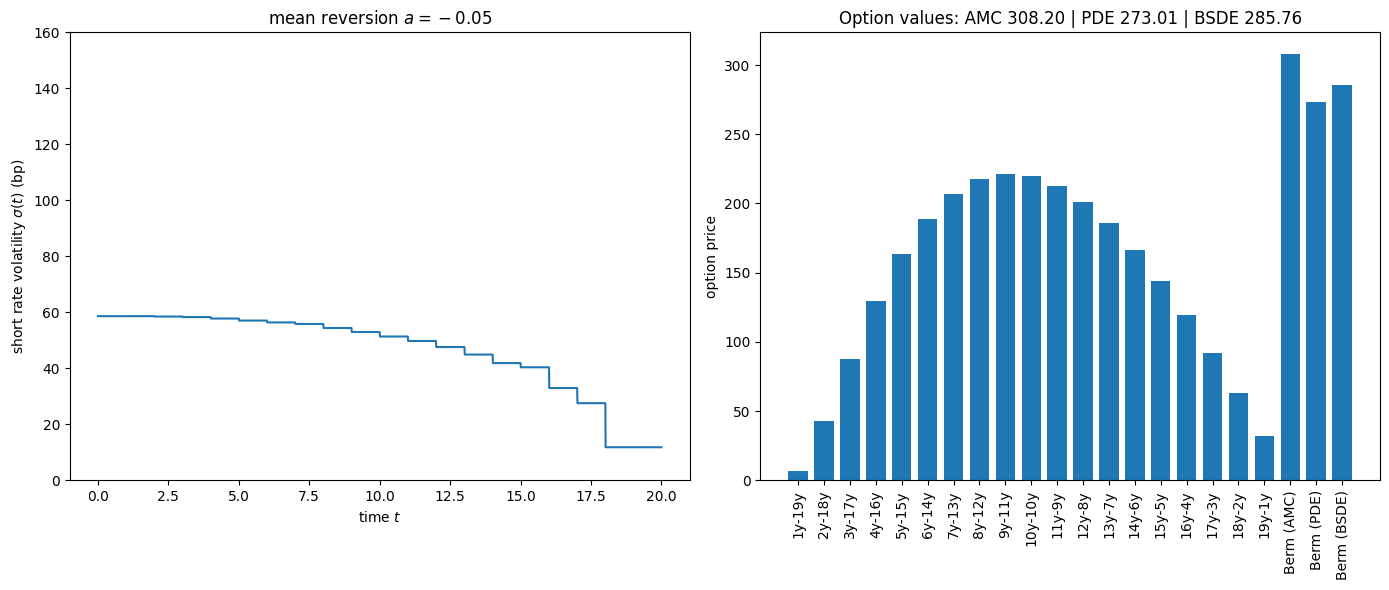

In [42]:
PlotHelpers.bermudan_pricing_analysis(maturity=20, strike=0.03, 
    rate=0.05, market_volatility=0.01, mean_reversion=-0.05, 
    plot_save_path="plots/10_-005_ITM.png", bsde_epochs=400, bsde_paths=50000)

Backward induction: 100%|██████████| 19/19 [00:00<00:00, 144.39it/s]


BSDE training:   0%|          | 0/400 [00:00<?, ?it/s]

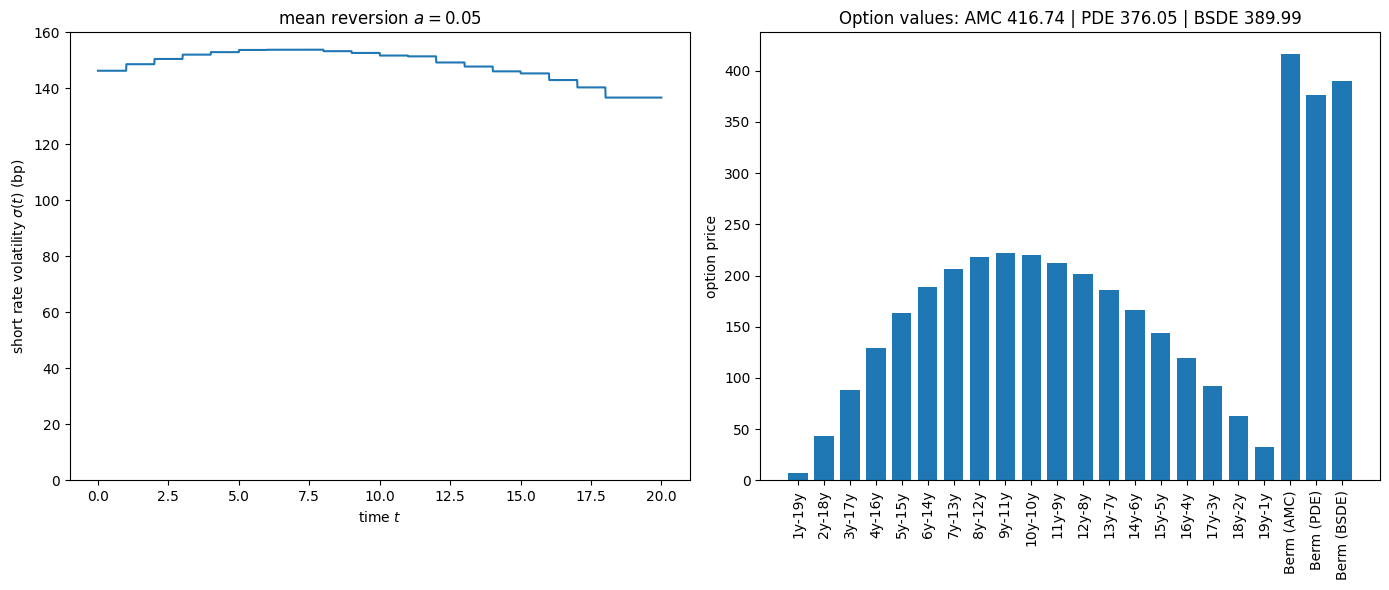

In [43]:
PlotHelpers.bermudan_pricing_analysis(maturity=20, strike=0.03, 
    rate=0.05, market_volatility=0.01, mean_reversion=0.05, 
    plot_save_path="plots/11_005_ITM.png", bsde_epochs=400, bsde_paths=50000)

Backward induction: 100%|██████████| 19/19 [00:00<00:00, 117.53it/s]


BSDE training:   0%|          | 0/400 [00:00<?, ?it/s]

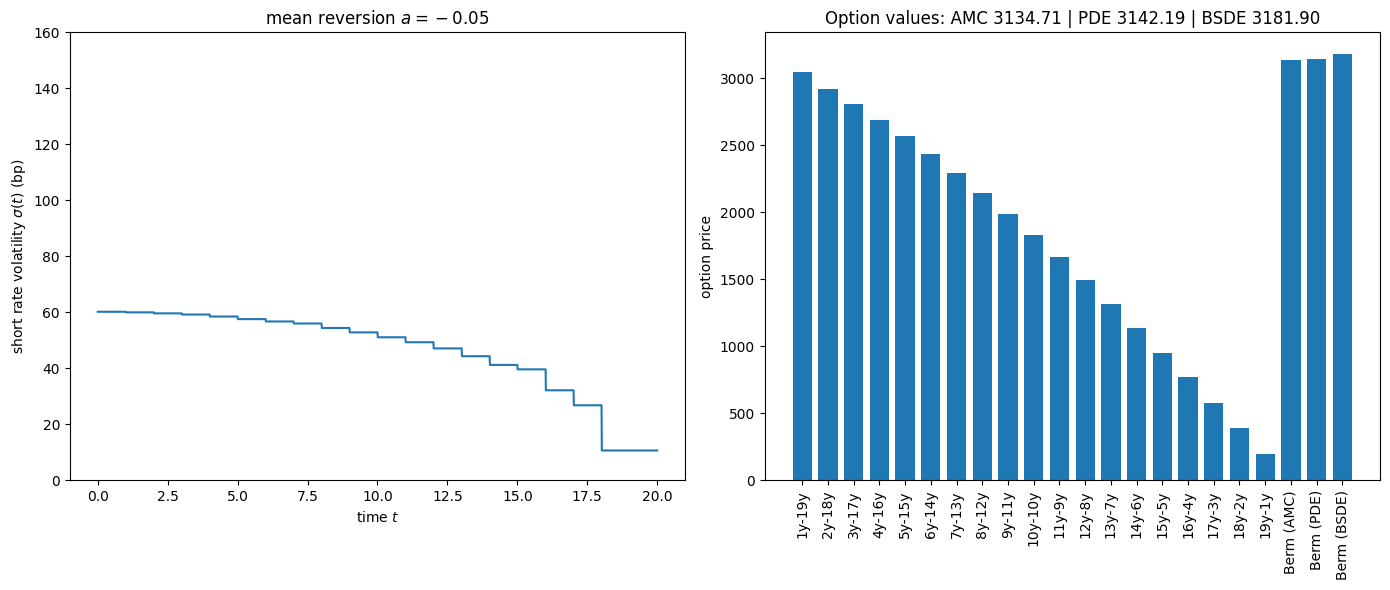

In [44]:
PlotHelpers.bermudan_pricing_analysis(maturity=20, strike=0.04, 
    rate=0.02, market_volatility=0.01, mean_reversion=-0.05, 
    plot_save_path="plots/12_-005_OTM.png", bsde_epochs=400, bsde_paths=50000)

Backward induction: 100%|██████████| 19/19 [00:00<00:00, 37.10it/s]


BSDE training:   0%|          | 0/400 [00:00<?, ?it/s]

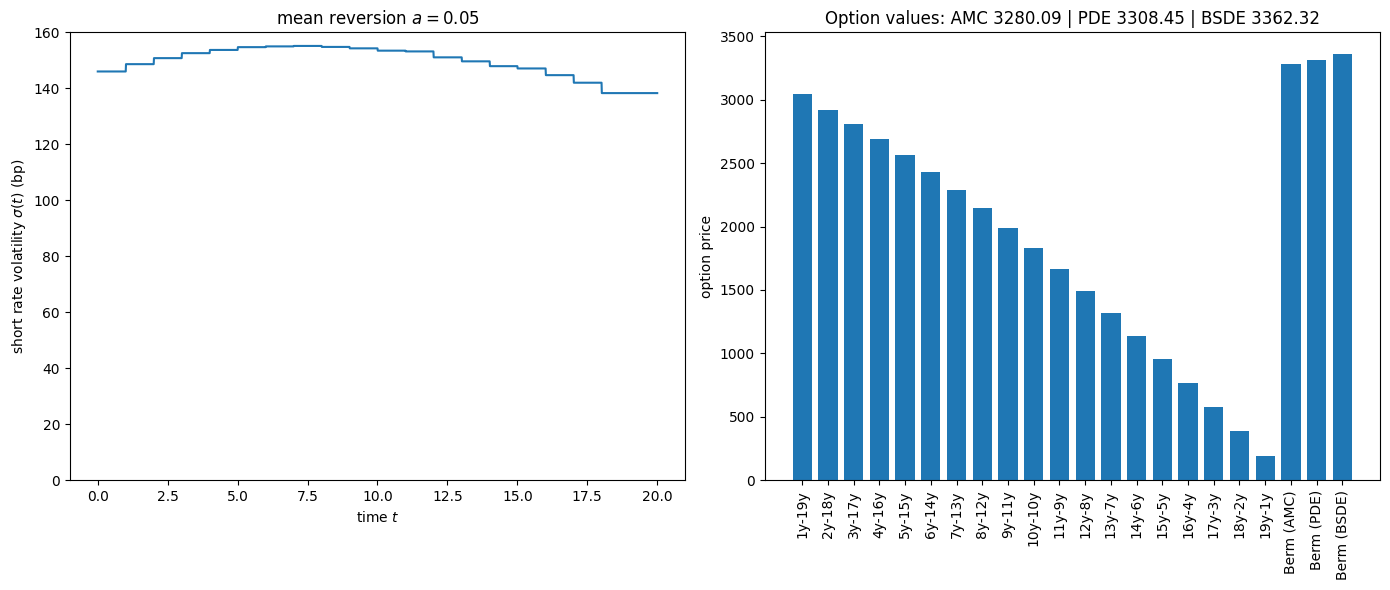

In [45]:
PlotHelpers.bermudan_pricing_analysis(maturity=20, strike=0.04, 
    rate=0.02, market_volatility=0.01, mean_reversion=0.05, 
    plot_save_path="plots/13_005_OTM.png", bsde_epochs=400, bsde_paths=50000)

Pricetables of AMC and BSDE prices for ITM, ATM and OTM Bermudan swaptions

In [29]:
strike = 0.03
options = [
    {'label': 'ITM', 'rate': 0.01},
    {'label': 'ATM', 'rate': 0.03},
    {'label': 'OTM', 'rate': 0.05},
]

mean_reversions = np.linspace(-0.05, 0.11, 9)
rows_amc        = []
rows_bsde       = []
rows_pde        = []

for a in mean_reversions:
    row_amc      = {'mean_reversion': a}
    row_bsde     = {'mean_reversion': a}
    row_pde      = {'mean_reversion': a}

    for opt in options:
        res = PlotHelpers.bermudan_pricing_analysis(
            maturity=20,
            strike=strike,
            rate=opt['rate'],
            market_volatility=0.01,
            mean_reversion=a,
            show_plots=False,
            bsde_epochs=300,
            bsde_paths=40000,
        )

        amc  = res['AMC']
        bsde = res['BSDE']
        pde  = res['PDE']

        row_amc[opt['label']]  = amc
        row_bsde[opt['label']] = bsde
        row_pde[opt['label']]  = pde

    rows_amc.append(row_amc)
    rows_bsde.append(row_bsde)
    rows_pde.append(row_pde)

Backward induction: 100%|██████████| 19/19 [00:00<00:00, 199.68it/s]


BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

Backward induction: 100%|██████████| 19/19 [00:00<00:00, 137.89it/s]


BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

Backward induction: 100%|██████████| 19/19 [00:00<00:00, 188.40it/s]


...

BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

Backward induction: 100%|██████████| 19/19 [00:00<00:00, 154.30it/s]


BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

Backward induction: 100%|██████████| 19/19 [00:00<00:00, 160.58it/s]


BSDE training:   0%|          | 0/300 [00:00<?, ?it/s]

In the following, we plot the resulting price tables for various ITM, ATM, and OTM Bermudan swaptions. The specifications are:

 >**ITM:** $r = 0.01,\; K = 0.03$ <br>
 >**ATM:** $r = 0.03,\; K = 0.03$ <br>
 >**OTM:** $r = 0.05,\; K = 0.03$

In [30]:
df_amc = pd.DataFrame(rows_amc)
df_amc.round(2)

,mean_reversion,ITM,ATM,OTM
0,-0.05,3524.46,1045.94,331.29
1,-0.03,3552.69,1089.26,351.42
2,-0.01,3584.71,1135.27,372.16
3,0.01,3620.42,1183.63,393.45
4,0.03,3659.67,1233.66,415.12
5,0.05,3702.35,1284.84,437.24
6,0.07,3748.09,1336.73,459.50
7,0.09,3796.56,1388.73,481.62
8,0.11,3847.26,1440.32,503.33


In [31]:
df_bsde = pd.DataFrame(rows_bsde)
df_bsde.round(2)

,mean_reversion,ITM,ATM,OTM
0,-0.05,3581.12,1113.59,287.64
1,-0.03,3609.09,1152.90,306.15
2,-0.01,3646.55,1198.64,326.88
3,0.01,3686.03,1245.35,349.21
4,0.03,3731.32,1294.61,371.31
5,0.05,3786.75,1341.49,390.68
6,0.07,3838.45,1391.55,413.84
7,0.09,3899.42,1439.59,433.13
8,0.11,3958.00,1486.57,457.54


In [32]:
df_pde = pd.DataFrame(rows_pde)
df_pde.round(2)

,mean_reversion,ITM,ATM,OTM
0,-0.05,3527.09,1068.65,273.01
1,-0.03,3554.87,1116.15,293.27
2,-0.01,3586.21,1160.38,313.63
3,0.01,3625.45,1205.49,334.15
4,0.03,3671.95,1253.35,355.03
5,0.05,3716.60,1300.51,376.05
6,0.07,3769.38,1347.16,396.95
7,0.09,3819.95,1393.32,417.82
8,0.11,3874.53,1438.78,438.48


Relative error of BSDE and AMC in percent

In [33]:
cols = ["ITM", "ATM", "OTM"]

df_amc_err  = df_amc.copy()
df_bsde_err = df_bsde.copy()
df_pde_err  = df_pde.copy()

df_amc_err[cols]  = ((df_amc[cols]  - df_pde[cols]).abs() / df_pde[cols].abs()) * 100
df_bsde_err[cols] = ((df_bsde[cols] - df_pde[cols]).abs() / df_pde[cols].abs()) * 100

In [34]:
df_amc_err.round(2)

,mean_reversion,ITM,ATM,OTM
0,-0.05,0.07,2.13,21.35
1,-0.03,0.06,2.41,19.83
2,-0.01,0.04,2.16,18.66
3,0.01,0.14,1.81,17.75
4,0.03,0.33,1.57,16.92
5,0.05,0.38,1.20,16.27
6,0.07,0.56,0.77,15.76
7,0.09,0.61,0.33,15.27
8,0.11,0.70,0.11,14.79


In [35]:
df_bsde_err.round(2)

,mean_reversion,ITM,ATM,OTM
0,-0.05,1.53,4.20,5.36
1,-0.03,1.53,3.29,4.39
2,-0.01,1.68,3.30,4.23
3,0.01,1.67,3.31,4.51
4,0.03,1.62,3.29,4.59
5,0.05,1.89,3.15,3.89
6,0.07,1.83,3.29,4.26
7,0.09,2.08,3.32,3.66
8,0.11,2.15,3.32,4.35


Although we can see a slight bias in the results towards higher prices for ITM and ATM swaptions and a bias towards lower prices for OTM swaptions, the overall structure remains valid. Thus, calibration to market prices would eliminate this bias and yields a realistic price structure.

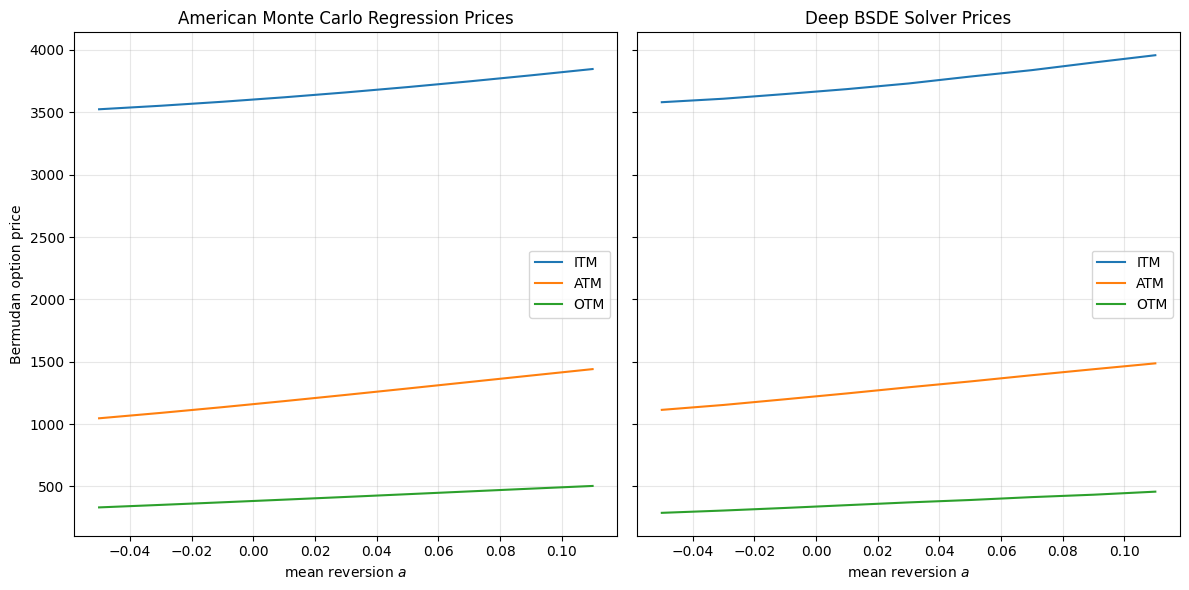

In [36]:
PlotHelpers.plot_bermudan_prices_amc_vs_bsde(berm_npv_amc=df_amc, 
    berm_npv_bsde=df_bsde, filename="plots/14_bermudan_option_prices_ITM_ATM_OTM.png")